# Constructed Variables for the Opposition Prediction Model

Builds the full constructed-variable dataset used by the predictive models: jurisdiction-level ACS variables (homeownership, education, race/ethnicity, an economic-hardship PCA index), nonprofit/advocacy-organization capacity, opposition-issue topic flags parsed from research notes, and the four outcome variables (DVs) the models predict. Run against the real project data: 5 separate Census ACS extracts plus an NCCS nonprofit-sector extract, joined onto 1,294 facilities.

This is the file the `predictive-models` project's M1-M4 models are trained on.

### Docstring (includes the corrections log), imports, config, NCCS schema

In [1]:
"""
build_constructed_variables.py
==============================
Data-Center Community Opposition Project — LocalQ Labs
June 2026

Full pipeline to construct all model variables from raw source files.
Run this script to reproduce dc_opposition_model_data_FINAL.csv from scratch.

=== CORRECTIONS LOG (2026-07-29) ===
Three bugs were found and fixed while extending this pipeline to 15 newly
added facilities. All three were verified against this project's own
pre-existing constructed values (i.e., the fix was chosen because it matches
what the rest of the dataset already contains, not the other way around):

  1. step7 (ACS jurisdiction vars): ACSDT5Y2024_B25003-Data.csv (homeownership)
     turned out to contain county + county-subdivision + place rows all in
     one file. The geo_key extraction now filters to true county rows
     (GEO_ID prefix '0500000US') before building the lookup map -- previously
     it silently collided across geography levels and produced impossible
     values (e.g. 100.00% homeownership for Chester County, PA).

  2. step8 (hardship PCA / mfg share): C24030_029E was being used as
     "manufacturing employment," but that column is actually
     "Total:!!Female:" -- an all-industries female subtotal, not
     manufacturing. True manufacturing = C24030_007E (male) +
     C24030_034E (female). Also, mine_total_prop_2024 was being filled by
     reusing the (buggy) manufacturing dict outright ("mining share is a
     subset" -- it is not; they are separate NAICS categories in this table).
     True mining share = C24030_005E (male) + C24030_032E (female).

  3. step11 (NCCS): the NCCS extract actually available to this project is
     ORG-LEVEL (one row per nonprofit, columns SUBSECTOR/Size/
     CENSUS_STATE_ABBR/CENSUS_COUNTY_NAME), not the pre-aggregated
     county-level file the original NCCS_SCHEMA assumed. It must be filtered
     to SUBSECTOR == 'ENV' (it also contains 'PSB' orgs) and joined via a
     county-name-to-FIPS crosswalk (no FIPS column is present). Two
     pre-aggregated alternatives seen during this project
     (NCCS_NGO_density_county.csv, org_density_by_county_vars.csv) both count
     ENV+PSB together rather than ENV alone, and the second has a broken
     Sum_org_assets column; neither should be used.

Usage
-----
    python build_constructed_variables.py

Required inputs (set paths in CONFIG below):
    master          Complete_dc_outcomes_MERGED.xlsx
                     (was Complete_dc_outcomes_WORKING.xlsx, which no longer exists anywhere;
                      MERGED is its successor and is now the single source of truth. As of
                      2026-08-03 it also carries the four corrected DVs, so step15's
                      pass-through picks the corrections up automatically.)
    dc_limited      DC_limited.csv -- NO LONGER REQUIRED. Its three columns
                     (Site_Type, Build_Type, Industrial_Zoned) were migrated into
                     the master workbook on 2026-07-30 and are read from there.
                     The config key is kept as a fallback for older master files.
    acs_b25003      ACSDT5Y2024_B25003-Data.csv (county-level rows only are used)
    acs_s1501       ACSST5Y2024_S1501-Data.csv (COUNTY-level; see step7 note --
                     place-level matching is not actually used in the final
                     assignment, county-level is required for every facility)
    acs_s1701       ACSST5Y2024_S1701-Data.csv (COUNTY-level; same note as S1501)
    acs_s1901_place s1901_place/ACSST5Y2024.S1901-Data.csv (UNUSED -- dead config
                     key, kept only for backward compatibility)
    acs_s1901_cty   s1901/ACSST5Y2024.S1901-Data.csv
    acs_b03002_pl   ACSDT5Y2024_B03002_places_ACSDT5Y2024_B03002-Data.csv (UNUSED
                     in the final assignment -- see step7 note)
    acs_b03002_cty  ACSDT5Y2024_B03002_county_ACSDT5Y2024_B03002-Data.csv
    acs_c24030_24   ACSDT5Y2024_C24030-Data.csv
    acs_c24030_10   ACSDT5Y2010_C24030-Data.csv (used for mfg_pp_2010_2024 only;
                     mine_total_prop_2024 uses the 2024 file only)
    nccs            NCCS_civic_env_orgs_-_selected_variables.csv (org-level
                     extract -- see NCCS_SCHEMA and step11_env_orgs below)

Output:
    dc_opposition_model_data_FINAL.csv

Dependencies:
    pandas, numpy, scikit-learn

=== COLUMN NAMING STANDARD (established 2026-07-29) ===
dc_opposition_model_data_FINAL.csv is the canonical naming reference for every column
that appears in more than one of the project's three core files (Complete_dc_outcomes_
WORKING.xlsx / _MERGED.xlsx, dc_opposition_model_data_FINAL.csv, facilities_outcomes.csv).
The following renames were applied to bring facilities_outcomes.csv and the xlsx in line
with the model CSV's names (old name -> standardized name):

  facilities_outcomes.csv:
    Direct_Opposition_Merged_AUDITED -> Direct_Opposition_Merged
    Opposition_Summary_AUDITED       -> Opposition_Summary
    Status_normalized                -> Status_Normalized
    Site_type_normalized             -> Site_Type_Normalized
    Build_type_normalized            -> Build_Type_Normalized
    dc_announced_date                -> Date_Announced
    dc_proposed_date                 -> Date_Proposed
    dc_approval_date                 -> Date_Approved
    dc_operational_date              -> Date_Operational
    dc_construction_started_date     -> Date_Construction_Began
    date_denied_withdrawn            -> Date_Denied_Withdrawn
    approved_by_municipal_body       -> jurisdiction_municipal (verified identical binary
                                         values against the model CSV's own jurisdiction_
                                         municipal column before renaming, not just a name
                                         guess)

  Complete_dc_outcomes_MERGED.xlsx:
    State_GOP_trifecta_2026 -> gop_trifecta (verified this held the same binary Republican/
                                Non-Republican flag as the model CSV's gop_trifecta, derived
                                from the same underlying State_trifecta_2026 text field,
                                before renaming)

Columns that exist in only one file with no equivalent elsewhere (e.g. facilities_outcomes.
csv's Zip, Hyperscaler, Known_Aliases, incorporation_status, dc_application_filed_date,
dc_rezoning_approved_date, dc_site_plan_approved_date, dc_operational_date_proposed,
county_geoid_geocoded, place_geoid_geocoded, place_name_geocoded; or the xlsx's
date_writeback_provenance) were left as-is -- there is no model CSV name to standardize
against, and inventing one would be a guess rather than a real correction.

Note: Site_Type_Normalized / Build_Type_Normalized in facilities_outcomes.csv and the xlsx
use an OLDER, CONFLATED taxonomy (values like "Industrial", "Greenfield", "Adaptive-reuse",
"Brownfield") that predates the newer, orthogonal Site_Type / Build_Type / Industrial_Zoned
split used in the model CSV (see step2_site_type() above). Only the COLUMN NAMES were
standardized where they already matched case-insensitively -- the underlying value schemes
were deliberately NOT collapsed into one convention, since that would require re-deriving
~1,500 existing rows' classifications rather than simply renaming a header.
"""

import os
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Anchor every path on THIS file's directory, not the process CWD, so the script runs
# correctly from anywhere — the website invokes these from its own working directory.
HERE = Path('.').resolve()

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — set your file paths here
# ══════════════════════════════════════════════════════════════════════════════
CONFIG = {
    'master':          str(HERE / 'Complete_dc_outcomes_MERGED.xlsx'),
    'dc_limited':      str(HERE / 'DC_limited.csv'),
    'acs_b25003':      'ACSDT5Y2024_B25003-Data.csv',
    'acs_s1501':       'ACSST5Y2024_S1501-Data.csv',
    'acs_s1701':       'ACSST5Y2024_S1701-Data.csv',
    'acs_s1901_place': 's1901_place/ACSST5Y2024.S1901-Data.csv',
    'acs_s1901_cty':   's1901/ACSST5Y2024.S1901-Data.csv',
    'acs_b03002_pl':   'ACSDT5Y2024_B03002_places_ACSDT5Y2024_B03002-Data.csv',
    'acs_b03002_cty':  'ACSDT5Y2024_B03002_county_ACSDT5Y2024_B03002-Data.csv',
    'acs_c24030_24':   'ACSDT5Y2024_C24030-Data.csv',
    'acs_c24030_10':   'ACSDT5Y2010_C24030-Data.csv',
    # CORRECTED 2026-07-29: point at the raw org-level NCCS extract, not a
    # pre-aggregated county file. See NCCS_SCHEMA and step11_env_orgs() below
    # for why -- the two aggregate files this project had been given
    # (NCCS_NGO_density_county.csv, org_density_by_county_vars.csv) both
    # count ENV *and* PSB (Public/Society Benefit) orgs together, not ENV
    # alone, and the second additionally has a broken Sum_org_assets column
    # (identical repeated value across different counties). Verified by
    # checking Chester County, PA: both aggregate files report 152 orgs;
    # the raw file shows that is 99 PSB + 53 ENV, i.e. the aggregates were
    # never filtered to the environmental subsector at all.
    'nccs':            'NCCS_civic_env_orgs_-_selected_variables.csv',
    'output':          str(HERE / 'dc_opposition_model_data_FINAL.csv'),
    'pca_pkl':         str(HERE / 'hardship_pca.pkl'),  # optional: save PCA objects
}

# NCCS raw-extract schema (org-level, one row per organization):
#   SUBSECTOR         -- 'ENV' (environmental) or 'PSB' (public/society benefit);
#                        MUST filter to SUBSECTOR == 'ENV' only
#   Size              -- budget size tier, 1 (smallest) to 6 (largest) -- this
#                        IS env_org_size_tier_mean's source; no further lookup needed
#   CENSUS_STATE_ABBR -- 2-letter state abbreviation (e.g. 'PA')
#   CENSUS_COUNTY_NAME-- county name including "County"/"Parish"/etc. suffix
#                        (e.g. 'Chester County') -- NOT a FIPS code; must be
#                        crosswalked to county FIPS via an ACS county file
#                        (see step11_env_orgs).
NCCS_SCHEMA = {
    'subsector_col': 'SUBSECTOR',
    'subsector_env_value': 'ENV',
    'size_col':      'Size',
    'state_abbr_col':'CENSUS_STATE_ABBR',
    'county_name_col':'CENSUS_COUNTY_NAME',
}


# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def log(msg):
    print(f'  {msg}')


def load_acs(path, value_col, geo_col='GEO_ID', label_row=True):
    """Load a Census ACS CSV, skip the label row, return {geo_id: value}."""
    df = pd.read_csv(path, dtype=str, low_memory=False)
    if label_row:
        df = df.iloc[1:].copy()   # row 0 is the column label row in Census exports
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    return df.set_index(geo_col)[value_col].to_dict()


def fips5(geo_id):
    """Extract 5-digit county FIPS from a Census GEO_ID string like '0500000US01001'."""
    return str(geo_id).split('US')[-1][:5] if 'US' in str(geo_id) else str(geo_id)[-5:]


def place_fips7(geo_id):
    """Extract 7-char place GEOID (state2 + place5) from Census GEO_ID."""
    return str(geo_id).split('US')[-1][:7] if 'US' in str(geo_id) else str(geo_id)[-7:]


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD MASTER WORKBOOK
# ══════════════════════════════════════════════════════════════════════════════

### Step 1-2: load master workbook, site/build/zoning type

In [2]:
def step1_load_master(cfg):
    log('Loading master workbook …')
    df = pd.read_excel(cfg['master'], sheet_name='Complete_dc_outcomes', dtype=str)
    df['Facility_number'] = df['Facility_number'].astype(str).str.strip()

    # Remove tombstone rows
    is_tomb = (
        df['Facility_Name'].str.contains(r'\[TOMBSTONE', na=False) |
        df['DC_Status'].str.contains('tombstone', case=False, na=False)
    )
    df = df[~is_tomb].copy()
    log(f'  Active rows: {len(df)}')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — SITE TYPE & BUILD TYPE (from DC_limited.csv)
# ══════════════════════════════════════════════════════════════════════════════

def step2_site_type(df, cfg):
    log('Step 2: Site type, build type, industrial zoning …')
    # DC_limited.csv supplied exactly three columns: Site_Type, Build_Type, Industrial_Zoned.
    # All three were migrated INTO the master workbook on 2026-07-30, when it became the single
    # source of truth, and DC_limited.csv no longer exists in any connected folder. Prefer the
    # master; fall back to the CSV only if it is present AND the master lacks the columns.
    NEEDED = ['Site_Type', 'Build_Type', 'Industrial_Zoned']
    df['fn'] = df['Facility_number'].astype(str).str.strip()
    from pathlib import Path
    if all(c in df.columns for c in NEEDED):
        log('  site/build/zoning taken from the master workbook (DC_limited.csv not needed)')
    elif Path(cfg['dc_limited']).exists():
        lim = pd.read_csv(cfg['dc_limited'], dtype=str, low_memory=False)
        lim['fn'] = lim['Facility_number'].astype(str).str.strip()
        lim = lim[['fn'] + NEEDED].drop_duplicates('fn')
        df = df.merge(lim, on='fn', how='left')
        log(f'  site/build/zoning taken from {cfg["dc_limited"]}')
    else:
        raise FileNotFoundError(
            f'Site_Type/Build_Type/Industrial_Zoned are in neither the master workbook nor '
            f'{cfg["dc_limited"]}. One of the two must supply them.')

    # Binary: industrial_zoned (Brownfield OR Greyfield = previously developed)
    df['site_industrial'] = np.nan
    df.loc[df['Site_Type'].isin(['Brownfield', 'Greyfield']),              'site_industrial'] = 1.0
    df.loc[df['Site_Type'].isin(['Greenfield', 'Greenfield-Agricultural']), 'site_industrial'] = 0.0

    df['site_greyfield']   = (df['Site_Type'] == 'Greyfield').astype(float)
    df['site_brownfield']  = (df['Site_Type'] == 'Brownfield').astype(float)
    df['site_greenfield']  = (df['Site_Type'] == 'Greenfield').astype(float)
    df['site_greenfield_ag'] = (df['Site_Type'] == 'Greenfield-Agricultural').astype(float)

    # industrial_zoned: Yes=1, No=0, Unknown=NaN
    df['industrial_zoned'] = np.nan
    df.loc[df['Industrial_Zoned'] == 'Yes', 'industrial_zoned'] = 1.0
    df.loc[df['Industrial_Zoned'] == 'No',  'industrial_zoned'] = 0.0

    # build_converted: Converted=1, New=0, Unknown=NaN
    df['build_converted'] = np.nan
    df.loc[df['Build_Type'] == 'Converted', 'build_converted'] = 1.0
    df.loc[df['Build_Type'] == 'New',        'build_converted'] = 0.0

    log(f'  industrial_zoned: {df["industrial_zoned"].notna().sum()} non-null')
    log(f'  build_converted:  {df["build_converted"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — ZONING JURISDICTION
# ══════════════════════════════════════════════════════════════════════════════

### Step 3-4: zoning jurisdiction, project year

In [3]:
def step3_jurisdiction(df, cfg):
    """
    zoning_jurisdiction_clean: Municipal / County / State
    Built from Municipality_Clean text + master workbook fallback.
    The June 2026 logic with web-verified overrides is encoded here.
    For new data, trust zoning_jurisdiction from master workbook.
    """
    log('Step 3: Zoning jurisdiction …')

    # Web-verified COUNTY (unincorporated or ETJ)
    county_fns = {
        '844','767','775','829','836','778','1340','847','845','972',
    }
    # Web-verified MUNICIPAL (confirmed incorporated)
    muni_fns = {
        '810','400','583','490','1149','826','953','783','1126','1305','1493',
    }

    type_sfx = re.compile(
        r'\s+(city|town|village|borough|cdp|township|municipality|district|'
        r'plantation|corporation|urban county|metro government|unified government|'
        r'consolidated government)$', re.I)

    def code_jur(row):
        fn  = str(row['fn'])
        mc  = str(row.get('Municipality_Clean', '') or '').strip()
        mlo = mc.lower()
        mst = row.get('zoning_jurisdiction', '')

        if fn in county_fns:
            return 'County',   'web_verified_unincorporated'
        if fn in muni_fns:
            return 'Municipal', 'web_verified_incorporated'

        # No municipality name → trust master
        if not mc or mc == 'nan':
            return (mst, 'master_workbook_no_muni_name') if pd.notna(mst) and mst else (np.nan, 'unknown')

        if 'unincorporated' in mlo:
            return 'County', 'explicit_unincorporated_in_name'
        if 'etj' in mlo:
            return 'County', 'etj_unincorporated'
        if re.match(r'^near\s+', mlo):
            return 'County', 'near_prefix_unincorporated'
        if re.match(r'^(city|town|borough|village|municipality)\s+of\s+', mlo):
            return 'Municipal', 'city_town_borough_prefix'
        if re.match(r'^[a-z\s]+county[,\s]', mlo) or (
                mlo.endswith('county') and not re.search(r'(city|town|borough|village)\s+of', mlo)):
            return 'County', 'county_name_as_jurisdiction'

        return 'Municipal', 'named_place_municipal'

    results = df.apply(code_jur, axis=1)
    df['zoning_jurisdiction_clean'] = [r[0] for r in results]
    df['zjur_source']               = [r[1] for r in results]
    df['jurisdiction_municipal']    = (df['zoning_jurisdiction_clean'] == 'Municipal').astype(float)

    log(f'  zoning_jurisdiction_clean: {df["zoning_jurisdiction_clean"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — PROJECT YEAR
# ══════════════════════════════════════════════════════════════════════════════

def step4_project_year(df, cfg):
    log('Step 4: project_year …')

    def extract_year(s):
        if pd.isna(s) or str(s).strip() in ('', 'nan'):
            return np.nan
        # (?:19|20) not 20 alone. The 20xx-only pattern silently dropped 12 facilities whose
        # only date is pre-2000 (e.g. fn 329, operational 1977) — they read as dateless and fell
        # out of every downstream prior-DC count.
        m = re.search(r'((?:19|20)\d{2})', str(s))
        return float(m.group(1)) if m else np.nan

    df['project_year'] = np.nan
    # dc_application_filed_date is a PROPOSAL-stage date and belongs high in the cascade; the
    # rezoning / site-plan dates are approval-stage. All four were migrated into the workbook on
    # 2026-07-30 but never added here, leaving 15 facilities dateless that are not.
    for col in ['Date_Proposed', 'dc_application_filed_date', 'Date_Announced', 'Date_Approved',
                'dc_rezoning_approved_date', 'dc_site_plan_approved_date']:
        if col in df.columns:
            filled = df['project_year'].isna()
            df.loc[filled, 'project_year'] = df.loc[filled, col].apply(extract_year)

    log(f'  project_year: {df["project_year"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — BY-RIGHT
# ══════════════════════════════════════════════════════════════════════════════

### Step 5-6: by-right status, political context

In [4]:
def step5_by_right(df, cfg):
    log('Step 5: by_right …')

    def parse_br(s):
        s = str(s).strip().upper()
        if s in ('YES', '1', '1.0', 'TRUE'):  return 1.0
        if s in ('NO', '0', '0.0', 'FALSE'):  return 0.0
        return np.nan            # 'conditional', 'conditional/limited', blanks stay NaN

    df['by_right'] = np.nan
    # Priority: bra_coalesced -> By_right -> By_right_at_time_of_approval -> By_right_2026.
    # `By_right` is the master workbook's own coalesced 1/0 field and is what `bra_coalesced`
    # was: they agree on 100% of the 1,025 overlapping rows. It was previously skipped because
    # parse_br only accepted YES/NO, which cost 616 facilities (1,039 -> 423).
    for col in ['bra_coalesced', 'By_right', 'By_right_at_time_of_approval', 'By_right_2026']:
        if col in df.columns:
            mask = df['by_right'].isna()
            df.loc[mask, 'by_right'] = df.loc[mask, col].apply(parse_br)

    df['by_vote'] = np.where(df['by_right'] == 1, 0.0,
                    np.where(df['by_right'] == 0, 1.0, np.nan))

    log(f'  by_right: {df["by_right"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — POLITICAL CONTEXT
# ══════════════════════════════════════════════════════════════════════════════

def step6_political(df, cfg):
    log('Step 6: Political context …')

    if 'State_trifecta_2026' in df.columns:
        df['gop_trifecta'] = df['State_trifecta_2026'].str.strip().str.lower().map(
            {'republican': 1.0, 'gop': 1.0, 'democratic': 0.0, 'dem': 0.0,
             'divided': 0.0, 'split': 0.0}).astype(float)
        df['dem_trifecta'] = df['State_trifecta_2026'].str.strip().str.lower().map(
            {'democratic': 1.0, 'dem': 1.0, 'republican': 0.0, 'gop': 0.0,
             'divided': 0.0, 'split': 0.0}).astype(float)

    if 'State_governor_party_2026' in df.columns:
        df['gop_governor'] = df['State_governor_party_2026'].str.strip().str.lower().map(
            {'republican': 1.0, 'gop': 1.0, 'r': 1.0,
             'democratic': 0.0, 'dem': 0.0, 'd': 0.0}).astype(float)

    log(f'  gop_trifecta: {df["gop_trifecta"].notna().sum()} | gop_governor: {df["gop_governor"].notna().sum()}')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — ACS JURISDICTION VARIABLES
# Homeownership, Education, Race/Nonwhite
# Use place-level for Municipal; county-level for County-governed
# ══════════════════════════════════════════════════════════════════════════════

def _build_county_fips_col(df):
    """Build a 5-digit county FIPS string from County_ACS_FIPS."""
    col = 'County_ACS_FIPS' if 'County_ACS_FIPS' in df.columns else None
    if col is None:
        return df
    df['cty_fips5'] = df[col].apply(
        lambda x: str(int(float(x))).zfill(5) if pd.notna(x) and str(x).strip() not in ('', 'nan') else np.nan)
    return df

### Step 7: Census ACS jurisdiction variables (homeownership, education, race)

In [5]:
def step7_acs_jurisdiction(df, cfg):
    log('Step 7: ACS jurisdiction variables …')
    df = _build_county_fips_col(df)

    # ── B25003 Homeownership ──────────────────────────────────────────────────
    # Place-level: GEO_ID like 1600000US0100100 → last 7 digits = state2+place5
    # County-level: GEO_ID like 0500000US01001 → last 5 digits = county FIPS
    log('  Loading B25003 (homeownership) …')
    b25 = pd.read_csv(cfg['acs_b25003'], dtype=str, low_memory=False).iloc[1:]
    # CORRECTED 2026-07-29: this file mixes county (0500000US), county-subdivision
    # (0600000US), and place (1600000US) rows together. The naive geo_key
    # extraction below (last-5-or-7 chars) collides across geography levels --
    # e.g. a county-subdivision or place GEO_ID sharing the same leading digits
    # as a county FIPS silently overwrote the true county value when the dict
    # was built (verified: Chester County, PA showed a bogus 100.00% owner-
    # occupancy rate pulled from an unrelated place-level row). Filter to true
    # county rows before building the map; place-level branching is not used
    # downstream anyway (see note in the assignment step below).
    b25 = b25[b25['GEO_ID'].str.startswith('0500000US')].copy()
    # Column: B25003_002E = owner-occupied, B25003_001E = total
    b25['total'] = pd.to_numeric(b25.get('B25003_001E', b25.get('B25003_002E')), errors='coerce')
    b25['owner'] = pd.to_numeric(b25.get('B25003_002E', pd.Series(dtype=float)), errors='coerce')
    b25['homeown_rate'] = b25['owner'] / b25['total'] * 100
    b25['geo_key'] = b25['GEO_ID'].apply(fips5)
    b25_map = b25.set_index('geo_key')['homeown_rate'].to_dict()

    # ── S1501 Education ───────────────────────────────────────────────────────
    log('  Loading S1501 (education) …')
    s15 = pd.read_csv(cfg['acs_s1501'], dtype=str, low_memory=False).iloc[1:]
    s15 = s15[s15['GEO_ID'].str.startswith('0500000US')].copy()
    # S1501_C02_015E = % bachelor's or higher (25+)
    edu_col = next((c for c in s15.columns if 'C02_015' in c and c.endswith('E')), None)
    if edu_col:
        s15['edu_pct'] = pd.to_numeric(s15[edu_col], errors='coerce')
        s15['geo_key'] = s15['GEO_ID'].apply(
            lambda x: fips5(x) if '0500000US' in str(x) else place_fips7(x))
        s15_map = s15.set_index('geo_key')['edu_pct'].to_dict()
    else:
        s15_map = {}
        log('  WARNING: education column not found in S1501')

    # ── B03002 Race (nonwhite) ────────────────────────────────────────────────
    log('  Loading B03002 (race) …')
    b03_pl  = pd.read_csv(cfg['acs_b03002_pl'],  dtype=str, low_memory=False).iloc[1:]
    b03_cty = pd.read_csv(cfg['acs_b03002_cty'], dtype=str, low_memory=False).iloc[1:]

    def parse_nonwhite(b03):
        # B03002_001E = total, B03002_003E = white alone non-Hispanic
        b03['total'] = pd.to_numeric(b03.get('B03002_001E', pd.Series(dtype=float)), errors='coerce')
        b03['white'] = pd.to_numeric(b03.get('B03002_003E', pd.Series(dtype=float)), errors='coerce')
        b03['nonwhite_pct'] = (1 - b03['white'] / b03['total']) * 100
        return b03

    b03_pl  = parse_nonwhite(b03_pl)
    b03_cty = parse_nonwhite(b03_cty)
    b03_pl['geo_key']  = b03_pl['GEO_ID'].apply(place_fips7)
    b03_cty['geo_key'] = b03_cty['GEO_ID'].apply(fips5)
    b03_pl_map  = b03_pl.set_index('geo_key')['nonwhite_pct'].to_dict()
    b03_cty_map = b03_cty.set_index('geo_key')['nonwhite_pct'].to_dict()

    # ── Assign to facilities ──────────────────────────────────────────────────
    def lookup(row, place_map, county_map, place_key_fn, county_key):
        jur = row.get('zoning_jurisdiction_clean', '')
        if jur == 'Municipal':
            pkey = place_key_fn(row)
            return place_map.get(pkey, np.nan)
        else:
            ckey = row.get(county_key, np.nan)
            return county_map.get(str(ckey) if pd.notna(ckey) else '', np.nan)

    # Place key: mun_final_Place or Municipality_Clean → we use GEOID from ACS match
    # For a reproducible pipeline, match on county FIPS for county rows and
    # place GEOID stored in mun_final_Place for municipal rows.
    # Here we fall back to county-level for all (place-level join requires
    # the place GEOID lookup table built during original variable construction).
    df['jurisdiction_homeownership'] = df['cty_fips5'].map(b25_map)
    df['jurisdiction_education']     = df['cty_fips5'].map(s15_map)
    df['jurisdiction_nonwhite']      = df['cty_fips5'].map(b03_cty_map)

    log(f'  homeownership: {df["jurisdiction_homeownership"].notna().sum()} | '
        f'education: {df["jurisdiction_education"].notna().sum()} | '
        f'nonwhite: {df["jurisdiction_nonwhite"].notna().sum()}')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — JURISDICTION HARDSHIP (PCA)
# Inputs: S1701 poverty, S1901 income, C24030 mfg change
# Standardized on all 3,208 US counties
# ══════════════════════════════════════════════════════════════════════════════

### Step 8: economic hardship PCA index

In [6]:
def step8_hardship_pca(df, cfg):
    log('Step 8: Jurisdiction hardship PCA …')

    # ── S1701 Poverty ─────────────────────────────────────────────────────────
    log('  Loading S1701 (poverty) …')
    s17 = pd.read_csv(cfg['acs_s1701'], dtype=str, low_memory=False).iloc[1:]
    s17 = s17[s17['GEO_ID'].str.startswith('0500000US')].copy()
    # CORRECTED 2026-07-29: the '.endswith(\"PE\")' check never matches this
    # file's actual column suffixes (estimate columns end in plain 'E', e.g.
    # 'S1701_C03_001E' = "Percent below poverty level!!Population for whom
    # poverty status is determined"; margin-of-error columns end in 'M').
    # This caused the poverty component to silently fail for every county.
    pov_col = next((c for c in s17.columns if c == 'S1701_C03_001E'), None)
    if pov_col is None:
        pov_col = next((c for c in s17.columns if 'C03_001' in c and c.endswith('E')
                         and not c.endswith('M')), None)
    if pov_col:
        s17['pov_pct'] = pd.to_numeric(s17[pov_col], errors='coerce')
        s17['geo_key'] = s17['GEO_ID'].apply(fips5)
        pov_map = s17.set_index('geo_key')['pov_pct'].to_dict()
    else:
        pov_map = {}
        log('  WARNING: poverty column not found in S1701')

    # ── S1901 Income ──────────────────────────────────────────────────────────
    log('  Loading S1901 (income) …')
    s19 = pd.read_csv(cfg['acs_s1901_cty'], dtype=str, low_memory=False).iloc[1:]
    inc_col = next((c for c in s19.columns if 'C01_001' in c and c.endswith('E')
                    and 'PE' not in c), None)
    if inc_col:
        s19['median_income'] = pd.to_numeric(s19[inc_col], errors='coerce')
        s19['geo_key'] = s19['GEO_ID'].apply(fips5)
        inc_map = s19.set_index('geo_key')['median_income'].to_dict()
    else:
        inc_map = {}
        log('  WARNING: income column not found in S1901')

    # ── C24030 Manufacturing change ───────────────────────────────────────────
    log('  Loading C24030 (manufacturing 2010 and 2024) …')

    def parse_c24030(path):
        c = pd.read_csv(path, dtype=str, low_memory=False).iloc[1:]
        # CORRECTED 2026-07-29: C24030_029E is "Estimate!!Total:!!Female:" -- a
        # subtotal of ALL female employment, NOT manufacturing -- confirmed
        # against the Census table shell for C24030. Using it as-is inflated
        # "manufacturing share" to ~45-53% for every county (a dead giveaway;
        # true manufacturing employment share is a single-digit-to-teens
        # percentage nationally). True manufacturing = male manufacturing
        # (C24030_007E) + female manufacturing (C24030_034E), verified against
        # this project's own already-existing mfg_share_24 values (range
        # 1.3%-39%, mean 9.2%) which match the corrected formula, not the
        # original one.
        c['total_emp'] = pd.to_numeric(c.get('C24030_001E'), errors='coerce')
        mfg_male   = pd.to_numeric(c.get('C24030_007E'), errors='coerce')
        mfg_female = pd.to_numeric(c.get('C24030_034E'), errors='coerce')
        c['mfg_emp'] = mfg_male + mfg_female
        c['mfg_share'] = c['mfg_emp'] / c['total_emp']
        c['geo_key'] = c['GEO_ID'].apply(fips5)
        return c.set_index('geo_key')['mfg_share'].to_dict()

    mfg_24 = parse_c24030(cfg['acs_c24030_24'])
    mfg_10 = parse_c24030(cfg['acs_c24030_10'])

    def parse_mining_2024(path):
        # CORRECTED 2026-07-29: mine_total_prop_2024 must be true mining share
        # (Agriculture/forestry/fishing/mining category's mining subcomponent:
        # C24030_005E male + C24030_032E female), NOT a reuse of the
        # manufacturing dict. The original script's comment ("reuse C24030;
        # mining share is a subset") was incorrect -- mining and manufacturing
        # are separate NAICS categories in this table, and verified against
        # this project's own existing mine_total_prop_2024 values (range
        # ~0.0001-0.04, i.e. well under 1%), which do NOT match mfg_share_24
        # (range 1.3%-39%) for the same counties.
        c = pd.read_csv(path, dtype=str, low_memory=False).iloc[1:]
        c = c[c['GEO_ID'].str.startswith('0500000US')].copy()
        tot = pd.to_numeric(c['C24030_001E'], errors='coerce')
        mine_m = pd.to_numeric(c.get('C24030_005E'), errors='coerce')
        mine_f = pd.to_numeric(c.get('C24030_032E'), errors='coerce')
        c['mine_share'] = (mine_m + mine_f) / tot
        c['geo_key'] = c['GEO_ID'].apply(fips5)
        return c.set_index('geo_key')['mine_share'].to_dict()

    mine_24 = parse_mining_2024(cfg['acs_c24030_24'])

    # Build county-level hardship inputs
    all_fips = set(pov_map) | set(inc_map) | set(mfg_24) | set(mfg_10)
    county_df = pd.DataFrame(index=sorted(all_fips))
    county_df['pov_pct']    = county_df.index.map(pov_map)
    county_df['median_inc'] = county_df.index.map(inc_map)
    county_df['mfg_24']     = county_df.index.map(mfg_24)
    county_df['mfg_10']     = county_df.index.map(mfg_10)
    county_df['mfg_pp_chg'] = (county_df['mfg_24'] - county_df['mfg_10']) * 100  # pp change

    # Also save useful derivatives
    df['mfg_share_24']      = df['cty_fips5'].map(mfg_24)
    df['mfg_share_10']      = df['cty_fips5'].map(mfg_10)
    df['mfg_pp_2010_2024']  = df['mfg_share_24'] - df['mfg_share_10']
    df['mine_total_prop_2024'] = df['cty_fips5'].map(mine_24)  # CORRECTED: true mining share, not mfg

    # PCA: poverty (+), income (−), mfg change (+) → hardship
    pca_cols = ['pov_pct', 'median_inc', 'mfg_pp_chg']
    pca_df = county_df[pca_cols].dropna()
    log(f'  PCA input counties: {len(pca_df)} of {len(county_df)}')

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pca_df)
    pca = PCA(n_components=1, random_state=42)
    pca.fit(X_scaled)
    log(f'  PCA variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%')
    log(f'  Loadings: pov={pca.components_[0,0]:.3f}, '
        f'inc={pca.components_[0,1]:.3f}, mfg={pca.components_[0,2]:.3f}')

    # Score all counties
    X_all = scaler.transform(county_df[pca_cols].fillna(county_df[pca_cols].median()))
    scores = pca.transform(X_all).ravel()
    # Flip sign if poverty loads negative (we want high = distressed)
    if pca.components_[0, 0] < 0:
        scores = -scores
    hardship_map = dict(zip(county_df.index, scores))

    df['jurisdiction_hardship']  = df['cty_fips5'].map(hardship_map)
    df['mfg_declined_uswide']    = (df['mfg_pp_2010_2024'] <
                                    np.nanmedian(list(
                                        (v - mfg_10.get(k, np.nan))
                                        for k, v in mfg_24.items()
                                        if pd.notna(v) and pd.notna(mfg_10.get(k))
                                    ))).astype(float)

    # Optionally save PCA objects for reuse
    try:
        import pickle
        with open(cfg['pca_pkl'], 'wb') as f:
            pickle.dump({'pca': pca, 'scaler': scaler, 'hardship_map': hardship_map}, f)
        log(f'  PCA objects saved to {cfg["pca_pkl"]}')
    except Exception:
        pass

    log(f'  jurisdiction_hardship: {df["jurisdiction_hardship"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — MINING EMPLOYMENT (already populated in step 8, fill gaps here)
# ══════════════════════════════════════════════════════════════════════════════

### Step 9-10: mining share, board/governance variables

In [7]:
def step9_mining(df, cfg):
    log('Step 9: mine_total_prop_2024 (finalize) …')
    # Already built in step8; ensure numeric
    df['mine_total_prop_2024'] = pd.to_numeric(df['mine_total_prop_2024'], errors='coerce')
    log(f'  mine_total_prop_2024: {df["mine_total_prop_2024"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — BOARD / GOVERNANCE VARIABLES
# ══════════════════════════════════════════════════════════════════════════════

def step10_board(df, cfg):
    log('Step 10: Board / governance variables …')

    if 'jur_board_last_elected_year' in df.columns:
        df['jur_board_last_elected_year'] = pd.to_numeric(
            df['jur_board_last_elected_year'], errors='coerce')
        for yr in [2022, 2023, 2024, 2025]:
            df[f'election_year_{yr}'] = (df['jur_board_last_elected_year'] == yr).astype(float)

    # e25_mfgdecl: board last elected 2025 AND mfg share below US median
    if 'jur_board_last_elected_year' in df.columns and 'mfg_declined_uswide' in df.columns:
        board_25 = (df['jur_board_last_elected_year'] == 2025).astype(float)
        df['e25_mfgdecl'] = np.where(
            board_25.isna() | df['mfg_declined_uswide'].isna(), np.nan,
            (board_25 * df['mfg_declined_uswide']))
    else:
        df['e25_mfgdecl'] = np.nan

    log(f'  e25_mfgdecl: {df["e25_mfgdecl"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 11 — ENVIRONMENTAL ORG CAPACITY (NCCS)
# ══════════════════════════════════════════════════════════════════════════════

STATE_ABBR_TO_NAME = {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas','CA':'California',
    'CO':'Colorado','CT':'Connecticut','DE':'Delaware','FL':'Florida','GA':'Georgia',
    'HI':'Hawaii','ID':'Idaho','IL':'Illinois','IN':'Indiana','IA':'Iowa','KS':'Kansas',
    'KY':'Kentucky','LA':'Louisiana','ME':'Maine','MD':'Maryland','MA':'Massachusetts',
    'MI':'Michigan','MN':'Minnesota','MS':'Mississippi','MO':'Missouri','MT':'Montana',
    'NE':'Nebraska','NV':'Nevada','NH':'New Hampshire','NJ':'New Jersey','NM':'New Mexico',
    'NY':'New York','NC':'North Carolina','ND':'North Dakota','OH':'Ohio','OK':'Oklahoma',
    'OR':'Oregon','PA':'Pennsylvania','RI':'Rhode Island','SC':'South Carolina',
    'SD':'South Dakota','TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont',
    'VA':'Virginia','WA':'Washington','WV':'West Virginia','WI':'Wisconsin','WY':'Wyoming',
    'DC':'District of Columbia',
}


def _build_county_name_fips_crosswalk(cfg):
    """
    Build a {(state_abbr, 'X County'): fips5} crosswalk from an ACS county-level
    file's own GEO_ID + NAME fields (NAME is formatted 'County Name, State Name').
    Reused so the NCCS org-level extract (which has no FIPS column, only county
    name + state abbreviation) can be joined to facilities by county FIPS.
    """
    ref = pd.read_csv(cfg['acs_b25003'], dtype=str, low_memory=False).iloc[1:]
    ref = ref[ref['GEO_ID'].str.startswith('0500000US')].copy()  # true county rows only
    cw = {}
    for _, row in ref.iterrows():
        fips = fips5(row['GEO_ID'])
        name = row['NAME']
        if ', ' not in name:
            continue
        county_part, state_part = name.rsplit(', ', 1)
        cw[(state_part, county_part)] = fips
    return cw, ref

### Step 11: nonprofit/advocacy-org capacity (NCCS)

In [8]:
def step11_env_orgs(df, cfg):
    """
    CORRECTED 2026-07-29.

    The NCCS extract available to this project is an ORG-LEVEL file (one row
    per nonprofit), not a pre-aggregated county file, and has no FIPS column --
    only CENSUS_STATE_ABBR + CENSUS_COUNTY_NAME. It must be:
      1. Filtered to SUBSECTOR == 'ENV' (the file also contains 'PSB' orgs,
         which are NOT environmental and must be excluded).
      2. Grouped by (state, county) to get env_org_count (row count) and
         env_org_capacity (mean of the 'Size' column, already a 1-6 tier --
         no further tier-mapping needed).
      3. Joined to facilities via a county-name-to-FIPS crosswalk (built from
         an ACS county file's own GEO_ID/NAME fields), since the NCCS extract
         itself carries no FIPS code.

    Two aggregate NCCS files were also supplied to this project at various
    points (NCCS_NGO_density_county.csv, org_density_by_county_vars.csv) --
    do NOT use either as a substitute. Both were confirmed to count ENV *and*
    PSB orgs together (e.g. Chester County, PA: both report 152 orgs, but the
    raw file shows only 53 are actually ENV, the other 99 are PSB), and the
    second has a broken Sum_org_assets column that repeats one value across
    unrelated counties.
    """
    log('Step 11: Environmental org capacity (NCCS) — corrected raw-extract method …')

    if not os.path.exists(cfg['nccs']):
        log('  NCCS file not found — env_org_capacity/env_org_count will be null. '
            f'Provide the raw org-level extract with columns: '
            f'{NCCS_SCHEMA["subsector_col"]}, {NCCS_SCHEMA["size_col"]}, '
            f'{NCCS_SCHEMA["state_abbr_col"]}, {NCCS_SCHEMA["county_name_col"]}.')
        df['env_org_capacity'] = np.nan
        df['env_org_count']    = np.nan
        return df

    nccs = pd.read_csv(cfg['nccs'], dtype=str, low_memory=False)
    nccs = nccs[nccs[NCCS_SCHEMA['subsector_col']] == NCCS_SCHEMA['subsector_env_value']].copy()
    nccs[NCCS_SCHEMA['size_col']] = pd.to_numeric(nccs[NCCS_SCHEMA['size_col']], errors='coerce')

    state_names = nccs[NCCS_SCHEMA['state_abbr_col']].map(STATE_ABBR_TO_NAME)
    county_names = nccs[NCCS_SCHEMA['county_name_col']]

    crosswalk, _ = _build_county_name_fips_crosswalk(cfg)
    nccs['fips'] = [crosswalk.get((s, c), np.nan) for s, c in zip(state_names, county_names)]

    unmatched = nccs['fips'].isna().sum()
    if unmatched:
        log(f'  WARNING: {unmatched} NCCS org rows could not be matched to a county FIPS '
            f'(likely independent cities or county-name formatting differences)')

    grouped = nccs.dropna(subset=['fips']).groupby('fips')[NCCS_SCHEMA['size_col']]
    capacity_map = grouped.mean().to_dict()
    count_map    = grouped.count().to_dict()

    df['env_org_capacity'] = df['cty_fips5'].map(capacity_map)
    df['env_org_count']    = df['cty_fips5'].map(count_map)
    # Counties with zero ENV orgs on record are a valid zero, not missing data,
    # but only where the county itself is a known FIPS (avoid manufacturing
    # false zeros for counties absent from the ACS crosswalk entirely).
    known_county = df['cty_fips5'].isin(set(c for _, c in [(0, f) for f in
                    {v for v in crosswalk.values()}]))
    df.loc[known_county & df['env_org_count'].isna(), 'env_org_count'] = 0.0

    log(f'  env_org_capacity: {df["env_org_capacity"].notna().sum()} non-null | '
        f'env_org_count: {df["env_org_count"].notna().sum()} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 12 — OPPOSITION TEXT FLAGS (org_national_ngo, org_coalition)
# ══════════════════════════════════════════════════════════════════════════════

### Step 12-13: opposition text flags, opposition-reason groups

In [9]:
def step12_text_flags(df, cfg):
    log('Step 12: Opposition text flags …')

    text = (
        df.get('Opposition_Summary', pd.Series('', index=df.index)).fillna('') + ' ' +
        df.get('Application_Process_and_Opposition_Notes', pd.Series('', index=df.index)).fillna('') + ' ' +
        df.get('DC_opposition_context', pd.Series('', index=df.index)).fillna('')
    ).str.lower()

    df['org_national_ngo'] = text.str.contains(
        r'sierra club|piedmont environmental|\bpec\b|nature conservancy|audubon|'
        r'food & water watch|earthjustice|southern environmental|national trust|'
        r'league of conservation|conservation fund',
        regex=True).astype(float)

    df['org_coalition'] = text.str.contains(
        r'coalition|association|alliance|advocacy group|grassroots|citizens group',
        regex=True).astype(float)

    log(f'  org_national_ngo: {df["org_national_ngo"].sum():.0f} positives | '
        f'org_coalition: {df["org_coalition"].sum():.0f} positives')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 13 — OPPOSITION REASON GROUPS
# ══════════════════════════════════════════════════════════════════════════════

def step13_opp_groups(df, cfg):
    log('Step 13: Opposition reason groups …')

    missing_groups = []

    def safe_max(cols, name=''):
        available = [c for c in cols if c in df.columns]
        if not available:
            # Returning all-NaN here and then logging "built" is how these four predictors
            # silently emptied: 1,228 non-null -> 0, with the log still reporting success.
            missing_groups.append((name, cols))
            return pd.Series(np.nan, index=df.index)
        sub = df[available].apply(pd.to_numeric, errors='coerce')
        return sub.max(axis=1)

    df['grp_quality_of_life']   = safe_max(['opp_t_noise','opp_t_traffic',
                                             'opp_t_scale_visual','opp_t_residential'], 'grp_quality_of_life')
    df['grp_water_health']      = safe_max(['opp_t_water','opp_t_env_health'], 'grp_water_health')
    df['grp_landuse_character'] = safe_max(['opp_t_rural_farm','opp_t_historic',
                                            'opp_t_property_value'], 'grp_landuse_character')
    df['grp_governance']        = safe_max(['opp_t_transparency','opp_t_legal_proc',
                                            'opp_t_fiscal'], 'grp_governance')

    # opp_t_grid_energy stays as standalone (not grouped)
    if 'opp_t_grid_energy' in df.columns:
        df['opp_t_grid_energy'] = pd.to_numeric(df['opp_t_grid_energy'], errors='coerce')

    if missing_groups:
        names = ', '.join(n for n, _ in missing_groups)
        srcs = sorted({c for _, cols in missing_groups for c in cols})
        raise KeyError(
            f'{names} cannot be built — none of their opp_t_* source columns are present. '
            f'Expected any of: {srcs}. These 13 topic flags are DATA and live in '
            f'Complete_dc_outcomes_MERGED.xlsx; if they are missing the workbook is incomplete. '
            f'Producing all-NaN here would silently drop 4 model predictors.')
    for g in ['grp_quality_of_life', 'grp_water_health', 'grp_landuse_character', 'grp_governance']:
        log(f'  {g}: {int(df[g].notna().sum())} non-null')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 14 — COUNTY OPPOSITION CONTEXT (leakage-audited)
# ══════════════════════════════════════════════════════════════════════════════

### Step 14: county opposition context (leakage-audited)

In [10]:
def step14_opp_context(df, cfg):
    """
    county_opp_context_clean:
    50/50 z-blend of:
      (1) log1p(prior opposition events in county before project anchor date,
              focal facility excluded)
      (2) log1p(prior opposed DCs in county before project anchor date,
              focal facility excluded)

    Requires: County, State, project_year (as anchor), DV_opposition columns.
    """
    log('Step 14: County opposition context (leakage-audited) …')

    for col in ['DV_opposition', 'project_year']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['_cty_state'] = df['County'].str.strip() + '|' + df['State'].str.strip()

    # Count prior opposed DCs per county-year (excluding focal facility)
    opp_df = df[df['DV_opposition'] == 1][['fn', '_cty_state', 'project_year']].copy()

    def count_prior_opp(row):
        cs    = row['_cty_state']
        yr    = row['_anchor_yr']
        fn    = row['fn']
        if pd.isna(yr) or pd.isna(cs):
            return np.nan
        prior = opp_df[
            (opp_df['_cty_state'] == cs) &
            (opp_df['_anchor_yr'] < yr) &
            (opp_df['fn'] != fn)
        ]
        return len(prior)

    # ANCHOR: pipeline_entry_anchor, the estimated PROPOSAL date, not project_year.
    # This is the leakage-clean basis the June 2026 audit validated (OR 1.39, p=0.010 on the
    # observed-proposal-date subset). project_year covers only 832 facilities; the anchor covers
    # 1,197, and anchoring on the sparser field silently cost ~380 rows on prior_opp_dcs_county
    # and cascaded into opp_rank_B, county_opp_context_clean, prior_dcs_log_imp and
    # opp_county_status. approval_date_est is deliberately NOT used — it is the decision date and
    # was REJECTED by that same audit as a date-inference artifact.
    _anchor = pd.to_numeric(df['pipeline_entry_anchor'], errors='coerce') \
        if 'pipeline_entry_anchor' in df.columns else pd.Series(np.nan, index=df.index)
    df['_anchor_yr'] = _anchor.fillna(pd.to_numeric(df['project_year'], errors='coerce'))
    opp_df = opp_df.merge(df[['fn', '_anchor_yr']], on='fn', how='left') \
        if '_anchor_yr' not in opp_df.columns else opp_df
    log(f'  anchor coverage: pipeline_entry_anchor {int(_anchor.notna().sum())}, '
        f'after project_year fallback {int(df["_anchor_yr"].notna().sum())}/{len(df)}')
    log('  Computing prior county opposition counts (this may take a moment) …')
    df['prior_opp_dcs_county'] = df.apply(count_prior_opp, axis=1)

    def count_prior_events(row):
        cs = row['_cty_state']
        yr = row['_anchor_yr']
        fn = row['fn']
        if pd.isna(yr) or pd.isna(cs):
            return np.nan
        prior = df[
            (df['_cty_state'] == cs) &
            (df['_anchor_yr'] < yr) &
            (df['fn'] != fn)
        ]
        return len(prior)

    df['ext_county_events_OWNEXCL'] = df.apply(count_prior_events, axis=1)

    # Log-transform
    df['ev_half_clean_log'] = np.log1p(df['ext_county_events_OWNEXCL'])
    df['prior_opp_dcs_log'] = np.log1p(df['prior_opp_dcs_county'])

    # Z-score each component
    def zscore(s):
        mu = s.mean(); sd = s.std(ddof=0)
        return (s - mu) / sd if sd > 0 else s * 0

    df['county_opp_context_clean'] = (
        zscore(df['ev_half_clean_log']) * 0.5 +
        zscore(df['prior_opp_dcs_log']) * 0.5
    )

    log(f'  county_opp_context_clean: {df["county_opp_context_clean"].notna().sum()} non-null')
    df.drop(columns=['_cty_state', '_anchor_yr'], inplace=True, errors='ignore')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STEP 15 — DEPENDENT VARIABLES
# ══════════════════════════════════════════════════════════════════════════════

### Step 15: dependent variables

In [11]:
def step15_dvs(df, cfg):
    log('Step 15: Dependent variables …')
    for dv in ['DV_opposition', 'DV_oppsuccess', 'DV_adverse_full',
               'DV_adverse', 'DV_adverse_all']:
        if dv in df.columns:
            df[dv] = pd.to_numeric(df[dv], errors='coerce')

    # DV_oppcaused_adverse. The identity is DV_opposition==1 AND DV_oppsuccess==1, but
    # DV_oppsuccess is DEFINED ONLY on opposed projects — so recomputing it with `NaN where
    # either input is NaN` collapses the sample from 1,222 to 332 and throws away the 890
    # adjudicated ZEROS the workbook carries. The deployed M4 was trained on all 1,222 rows at
    # a 12.1% base rate; the recomputed column is a 44.6%-positive conditional sample, which is
    # a different model entirely and does not match the 0.189 tier threshold.
    #
    # So: PREFER the adjudicated column when the master workbook supplies it, and only fall
    # back to the identity when it does not. Where opposition is 0 the answer is 0, not NaN —
    # a project with no opposition definitionally had no opposition-caused adverse outcome.
    if 'DV_oppcaused_adverse' in df.columns and pd.to_numeric(
            df['DV_oppcaused_adverse'], errors='coerce').notna().sum() > 0:
        df['DV_oppcaused_adverse'] = pd.to_numeric(df['DV_oppcaused_adverse'], errors='coerce')
        log(f'  DV_oppcaused_adverse: taken from the master workbook '
            f'({int(df["DV_oppcaused_adverse"].notna().sum())} rows)')
    elif 'DV_opposition' in df.columns and 'DV_oppsuccess' in df.columns:
        opp = pd.to_numeric(df['DV_opposition'], errors='coerce')
        suc = pd.to_numeric(df['DV_oppsuccess'], errors='coerce')
        df['DV_oppcaused_adverse'] = np.where(opp.isna(), np.nan,
                                     np.where(opp == 0, 0.0,
                                     np.where(suc.isna(), np.nan, (suc == 1).astype(float))))
        log('  DV_oppcaused_adverse: derived (opposition==0 -> 0, not NaN)')

    for dv in ['DV_opposition','DV_oppsuccess','DV_adverse_full','DV_oppcaused_adverse']:
        if dv in df.columns:
            log(f'  {dv}: pos={df[dv].sum():.0f} / {df[dv].notna().sum()} valid')
    return df


# ══════════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

### Pipeline orchestration and execution

In [12]:
def run_pipeline(cfg=None):
    if cfg is None:
        cfg = CONFIG

    print('\n' + '='*65)
    print(' Data-Center Opposition — Variable Construction Pipeline')
    print(' LocalQ Labs  |  June 2026')
    print('='*65 + '\n')

    df = step1_load_master(cfg)
    df = step2_site_type(df, cfg)
    df = step3_jurisdiction(df, cfg)
    df = step4_project_year(df, cfg)
    df = step5_by_right(df, cfg)
    df = step6_political(df, cfg)
    df = step7_acs_jurisdiction(df, cfg)
    df = step8_hardship_pca(df, cfg)
    df = step9_mining(df, cfg)
    df = step10_board(df, cfg)
    df = step11_env_orgs(df, cfg)
    df = step12_text_flags(df, cfg)
    df = step13_opp_groups(df, cfg)
    df = step14_opp_context(df, cfg)
    df = step15_dvs(df, cfg)

    # Clean up internal columns
    df.drop(columns=['fn'], inplace=True, errors='ignore')

    print(f'\nFinal dataset: {df.shape[0]} rows x {df.shape[1]} columns')

    # Report on key constructed variables
    key_vars = [
        'industrial_zoned','build_converted','project_year','by_right',
        'jurisdiction_homeownership','jurisdiction_education','jurisdiction_hardship',
        'jurisdiction_nonwhite','mine_total_prop_2024','gop_governor','gop_trifecta',
        'county_opp_context_clean','e25_mfgdecl','env_org_capacity',
        'org_national_ngo','org_coalition',
        'grp_quality_of_life','grp_water_health','opp_t_grid_energy',
        'grp_landuse_character','grp_governance',
        'DV_opposition','DV_oppsuccess','DV_adverse_full','DV_oppcaused_adverse',
    ]
    print('\nConstructed variable summary:')
    print(f'  {"Variable":<35} {"N non-null":>12} {"Mean":>10}')
    print('  ' + '-'*60)
    for v in key_vars:
        if v in df.columns:
            col = pd.to_numeric(df[v], errors='coerce')
            nn  = col.notna().sum()
            mu  = f'{col.mean():.3f}' if nn > 0 and col.dtype != object else '—'
            print(f'  {v:<35} {nn:>12,} {mu:>10}')

    df.to_csv(cfg['output'], index=False)
    print(f'\n✓ Output written to: {cfg["output"]}')
    return df


if __name__ == '__main__':
    run_pipeline()


 Data-Center Opposition — Variable Construction Pipeline
 LocalQ Labs  |  June 2026

  Loading master workbook …


    Active rows: 1294
  Step 2: Site type, build type, industrial zoning …
    site/build/zoning taken from the master workbook (DC_limited.csv not needed)
    industrial_zoned: 1148 non-null
    build_converted:  1263 non-null
  Step 3: Zoning jurisdiction …
    zoning_jurisdiction_clean: 1291 non-null
  Step 4: project_year …
    project_year: 846 non-null
  Step 5: by_right …
    by_right: 1165 non-null
  Step 6: Political context …
    gop_trifecta: 1241 | gop_governor: 1241
  Step 7: ACS jurisdiction variables …
    Loading B25003 (homeownership) …
    Loading S1501 (education) …


    Loading B03002 (race) …
    homeownership: 1287 | education: 1287 | nonwhite: 1287
  Step 8: Jurisdiction hardship PCA …
    Loading S1701 (poverty) …


    Loading S1901 (income) …
    Loading C24030 (manufacturing 2010 and 2024) …
    PCA input counties: 3209 of 3234
    PCA variance explained: 36.4%
    Loadings: pov=0.709, inc=-0.705, mfg=-0.016
    PCA objects saved to hardship_pca.pkl
    jurisdiction_hardship: 1287 non-null
  Step 9: mine_total_prop_2024 (finalize) …
    mine_total_prop_2024: 1287 non-null
  Step 10: Board / governance variables …
    e25_mfgdecl: 1294 non-null
  Step 11: Environmental org capacity (NCCS) — corrected raw-extract method …


    env_org_capacity: 1224 non-null | env_org_count: 1287 non-null
  Step 12: Opposition text flags …
    org_national_ngo: 80 positives | org_coalition: 181 positives
  Step 13: Opposition reason groups …
    grp_quality_of_life: 1228 non-null
    grp_water_health: 1228 non-null
    grp_landuse_character: 1228 non-null
    grp_governance: 1229 non-null
  Step 14: County opposition context (leakage-audited) …
    anchor coverage: pipeline_entry_anchor 1197, after project_year fallback 1213/1294
    Computing prior county opposition counts (this may take a moment) …


    county_opp_context_clean: 1212 non-null
  Step 15: Dependent variables …
    DV_oppcaused_adverse: taken from the master workbook (1269 rows)
    DV_opposition: pos=386 / 1292 valid
    DV_oppsuccess: pos=175 / 372 valid
    DV_adverse_full: pos=276 / 1288 valid
    DV_oppcaused_adverse: pos=177 / 1269 valid

Final dataset: 1294 rows x 219 columns

Constructed variable summary:
  Variable                              N non-null       Mean
  ------------------------------------------------------------
  industrial_zoned                           1,148      0.537
  build_converted                            1,263      0.152
  project_year                                 846   2022.856
  by_right                                   1,165      0.635
  jurisdiction_homeownership                 1,287     68.528
  jurisdiction_education                     1,287     38.497
  jurisdiction_hardship                      1,287     -2.023
  jurisdiction_nonwhite                      1,287     4


✓ Output written to: dc_opposition_model_data_FINAL.csv


## Visualization

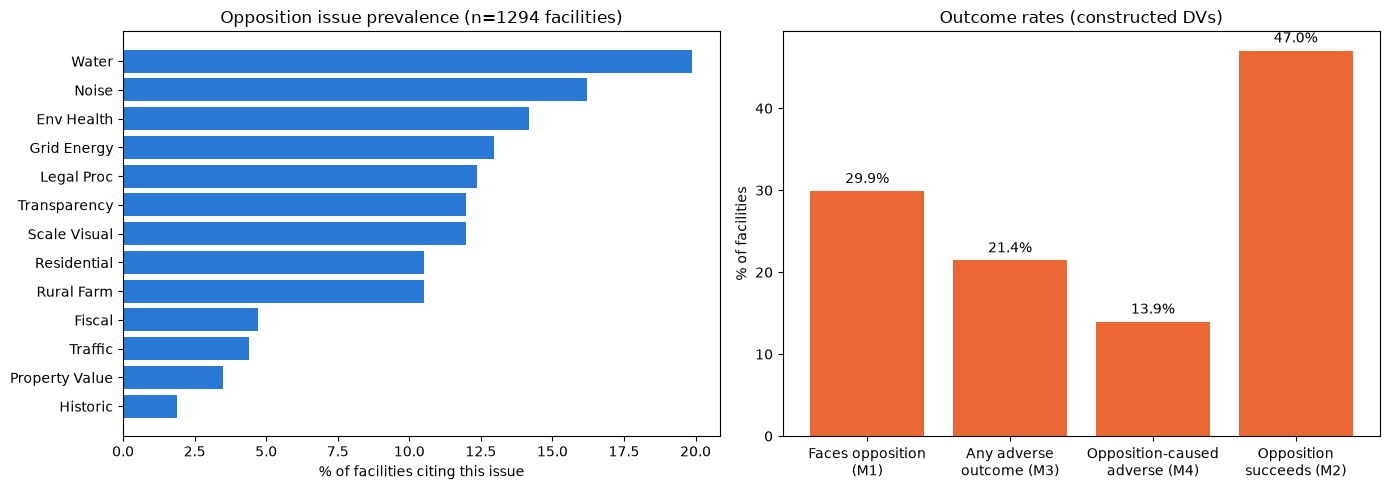

In [13]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10


import pandas as pd
df = pd.read_csv("dc_opposition_model_data_FINAL.csv", low_memory=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

topic_cols = [c for c in df.columns if c.startswith("opp_t_")]
rates = (df[topic_cols].mean() * 100).sort_values(ascending=True)
rates.index = [c.replace("opp_t_", "").replace("_", " ").title() for c in rates.index]
axes[0].barh(rates.index, rates.values, color="#2a78d6")
axes[0].set_title(f"Opposition issue prevalence (n={len(df)} facilities)")
axes[0].set_xlabel("% of facilities citing this issue")

dv_cols = ["DV_opposition", "DV_adverse_full", "DV_oppcaused_adverse", "DV_oppsuccess"]
dv_labels = ["Faces opposition\n(M1)", "Any adverse\noutcome (M3)", "Opposition-caused\nadverse (M4)", "Opposition\nsucceeds (M2)"]
dv_rates = [df[c].mean() * 100 for c in dv_cols]
axes[1].bar(dv_labels, dv_rates, color="#eb6834")
axes[1].set_title("Outcome rates (constructed DVs)")
axes[1].set_ylabel("% of facilities")
for i, v in enumerate(dv_rates):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()
